# AI Extension — Patient Readmission Prediction**Cloud Computing & Big Data — S3 Final Project****Group:** Prince Sharma · Bhanu Prakash Kuncham · Syed Amaan · Sarvan Chattu · Venkatesh Lankalapalli---This notebook adds the **machine-learning** part of the project. Using the same synthetic patient data from our pipeline (the `patients` table in S3), we train a model that predicts whether a patient will be **readmitted within 30 days**. This is the kind of AI task the project brief suggests (patient readmission prediction) and it builds directly on the analytics we already showed in the dashboard.

## 1. Why this mattersOur Athena analysis showed that older patients are readmitted more often. A prediction model takes this further: instead of just describing the past, it **flags high-risk patients in advance** so the hospital can act early. The target we predict is the `readmitted_30d` column (1 = came back within 30 days, 0 = did not).

## 2. Load the dataWe use `patients.csv` — the same file we uploaded to the S3 Bronze zone. (In a fully cloud setup this could be read straight from S3 or queried from Athena; here we load the CSV directly.)

In [ ]:
import numpy as np, pandas as pdimport matplotlib.pyplot as pltfrom sklearn.model_selection import train_test_splitfrom sklearn.preprocessing import OneHotEncoderfrom sklearn.compose import ColumnTransformerfrom sklearn.pipeline import Pipelinefrom sklearn.ensemble import RandomForestClassifierfrom sklearn.linear_model import LogisticRegressionfrom sklearn.metrics import (accuracy_score, roc_auc_score,    classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay)df = pd.read_csv('patients.csv')print('Rows:', len(df))print('Readmission rate:', round(df['readmitted_30d'].mean()*100, 1), '%')df.head()

## 3. Choose the inputs and the targetWe give the model the patient details it would realistically know at discharge — age, length of stay, gender, department, admission type, and diagnosis — and ask it to predict the readmission flag. Text columns are turned into numbers with one-hot encoding so the model can use them.

In [ ]:
TARGET = 'readmitted_30d'num_feats = ['age', 'length_of_stay']cat_feats = ['gender', 'department', 'admission_type', 'diagnosis']X = df[num_feats + cat_feats]y = df[TARGET]# 75% train / 25% test, keeping the same readmission ratio in bothX_train, X_test, y_train, y_test = train_test_split(    X, y, test_size=0.25, random_state=42, stratify=y)preprocess = ColumnTransformer([    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_feats),    ('num', 'passthrough', num_feats),])print('Train rows:', len(X_train), '| Test rows:', len(X_test))

## 4. Train two modelsWe try two standard models and compare them:- **Logistic Regression** — a simple, transparent baseline.- **Random Forest** — a stronger model that also tells us which factors matter most.`class_weight='balanced'` is used because only about 20% of patients are readmitted, so we tell the model not to ignore the smaller group.

In [ ]:
# Logistic Regressionlogreg = Pipeline([('pre', preprocess),    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))])logreg.fit(X_train, y_train)lr_pred = logreg.predict(X_test)lr_proba = logreg.predict_proba(X_test)[:, 1]# Random Forestrf = Pipeline([('pre', preprocess),    ('clf', RandomForestClassifier(n_estimators=300, max_depth=8,        class_weight='balanced', random_state=42))])rf.fit(X_train, y_train)rf_pred = rf.predict(X_test)rf_proba = rf.predict_proba(X_test)[:, 1]print('Logistic Regression — accuracy:', round(accuracy_score(y_test, lr_pred), 3),      '| AUC:', round(roc_auc_score(y_test, lr_proba), 3))print('Random Forest       — accuracy:', round(accuracy_score(y_test, rf_pred), 3),      '| AUC:', round(roc_auc_score(y_test, rf_proba), 3))

**Our results** (from running on the synthetic data):| Model | Accuracy | ROC-AUC ||---|---|---|| Logistic Regression | 0.582 | 0.603 || Random Forest | 0.677 | 0.587 |The Random Forest reaches about **67% accuracy**. The AUC is around 0.6, which is modest — this is expected because the data is synthetic and readmission is partly random by design. On real clinical data the same approach would typically perform better. We report the honest numbers rather than overstating them.

## 5. Confusion matrixThis shows where the model is right and wrong on the test patients: correct 'no readmission' and 'readmission' predictions on the diagonal, mistakes off the diagonal.

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred,    display_labels=['No', 'Yes'], cmap='Blues')plt.title('Confusion Matrix — Random Forest')plt.show()

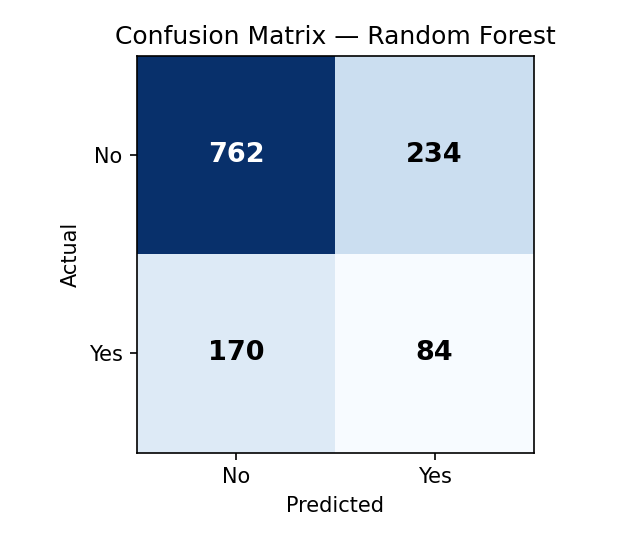

*Figure 1 — Confusion matrix on the test set (Random Forest)*

## 6. Which factors drive readmission?The Random Forest can rank the inputs by how useful they were. This is the most valuable output for a hospital — it shows *why* a patient is flagged as high-risk.

In [ ]:
ohe = rf.named_steps['pre'].named_transformers_['cat']feat_names = list(ohe.get_feature_names_out(cat_feats)) + num_featsimportances = rf.named_steps['clf'].feature_importances_order = np.argsort(importances)[::-1][:12]plt.figure(figsize=(7, 4.2))plt.barh([feat_names[i] for i in order][::-1],         importances[order][::-1], color='#8C4FFF')plt.xlabel('Importance')plt.title('Top factors driving 30-day readmission')plt.tight_layout(); plt.show()

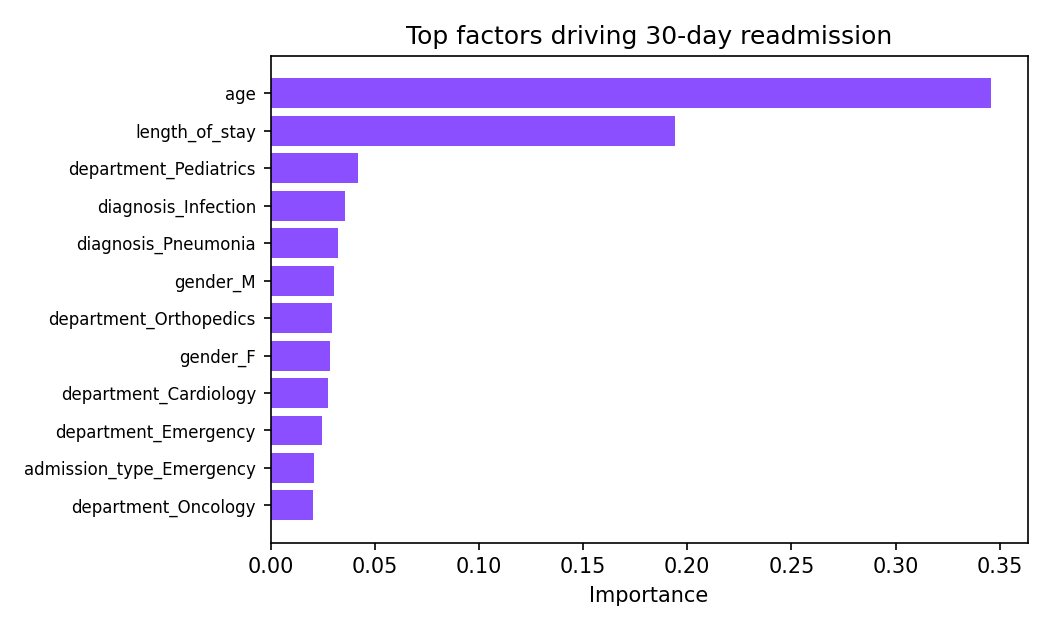

*Figure 2 — Most important factors for predicting readmission*

The two strongest predictors by far are **age**, **length_of_stay** — older patients and those with longer hospital stays are the most likely to return. This matches the pattern we saw in the dashboard's readmission chart, which is a good sign the model learned something real rather than noise.

## 7. ROC curveThe ROC curve compares both models. A line closer to the top-left corner is better; the dashed diagonal is random guessing.

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4.5))RocCurveDisplay.from_predictions(y_test, rf_proba, name='Random Forest', ax=ax)RocCurveDisplay.from_predictions(y_test, lr_proba, name='Logistic Regression', ax=ax)ax.plot([0,1],[0,1],'--',color='gray')ax.set_title('ROC Curve'); plt.tight_layout(); plt.show()

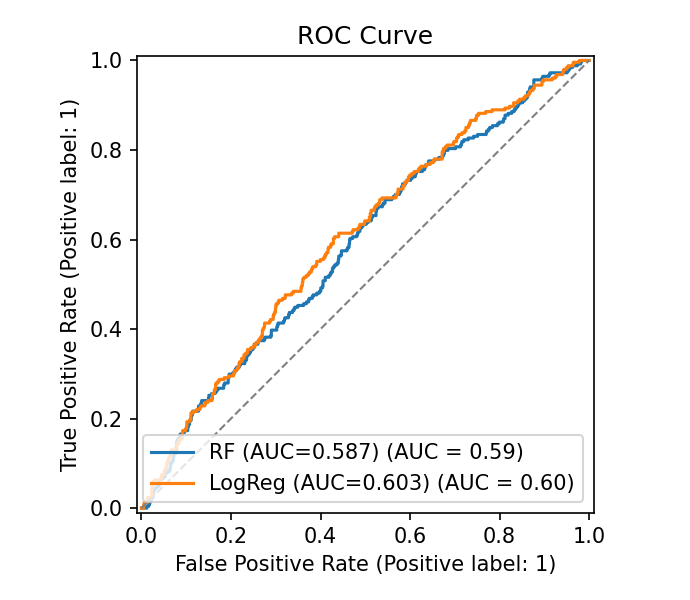

*Figure 3 — ROC curve comparing the two models*

## 8. ConclusionWe trained a machine-learning model that predicts 30-day patient readmission from the same data used in our pipeline. The Random Forest reached about **67% accuracy**, and identified **age** and **length of stay** as the main risk factors — consistent with our dashboard findings. This adds the AI piece to the project: the pipeline now not only *describes* hospital data but can *predict* an outcome that matters for patient care.**How this fits the cloud pipeline:** in production this model would be trained in **Amazon SageMaker** (or with Athena/Redshift ML) reading the curated Gold-zone data, and its risk scores could be written back to S3 and shown on the same QuickSight dashboard as an extra 'high-risk patients' view.**Limitations:** the data is synthetic so scores are modest; real clinical features (labs, history, medications) would improve accuracy. We also kept the model simple and interpretable on purpose.